In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Titanic Survival Machine Learning Pipeline

## Step 1: Load Dataset

In this step, we load the Titanic dataset into a pandas DataFrame and check whether the data has been imported correctly.

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [123]:
df = pd.read_csv("../data/titanic_real_world_missing_values_dataset.csv")

In [124]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [125]:
df.shape

(891, 12)

In [126]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [127]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [128]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Step 2: Initial Data Inspection

In this step, we check the dataset shape, column names, first few records, and data types. This helps us understand the structure of the dataset before cleaning or analysis.

## Step 3: Identify Target Column

In this step, we identify the target variable that the machine learning model needs to predict.

For this dataset, the target column is `Survived`.

- `0` = Passenger did not survive
- `1` = Passenger survived

This means the project is a binary classification problem.

In [129]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [130]:
target_col = "Survived"

In [131]:
df[target_col].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [132]:
df[target_col].value_counts(normalize=True) * 100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

### Step 3 Findings

The target column is `Survived`.

This is a binary classification problem because the target has two possible values:

- `0`: Passenger did not survive
- `1`: Passenger survived

The target distribution shows that more passengers did not survive than survived, so class distribution should be considered during model evaluation.

## Step 4: Check Missing Values

In this step, we check missing values in the dataset.

Missing values are important because machine learning models cannot properly learn from incomplete data. Before training a model, we need to identify which columns contain missing values and decide how to handle them.


In [133]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [134]:
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent
})

missing_summary

,missing_count,missing_percent
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
Age,177,19.865320
SibSp,0,0.000000
Parch,0,0.000000
Ticket,0,0.000000
Fare,0,0.000000


In [135]:
missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_percent
Age,177,19.865320
Cabin,687,77.104377
Embarked,2,0.224467


In [136]:
missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_percent
Age,177,19.865320
Cabin,687,77.104377
Embarked,2,0.224467


### Step 4 Findings

The dataset contains missing values in the following columns:

- `Age`: around 20% missing values
- `Cabin`: around 77% missing values
- `Embarked`: very few missing values

Cleaning decisions:

- `Age` will be filled using the median value because it is a useful numerical feature.
- `Cabin` will be dropped because it has too many missing values.
- `Embarked` will be filled using the mode because it is a categorical feature with very few missing values.

## Step 5: Check Duplicate Records

In this step, we check whether the dataset contains duplicate rows.

Duplicate records can affect analysis and model training because repeated rows may bias the model. Therefore, duplicates should be identified and removed if necessary.

In [137]:
df.duplicated().sum()

np.int64(0)

In [138]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [139]:
df = df.drop_duplicates()

In [140]:
print("Duplicate rows after cleaning:", df.duplicated().sum())
print("Dataset shape after duplicate check:", df.shape)

Duplicate rows after cleaning: 0
Dataset shape after duplicate check: (891, 12)


### Step 5 Findings

The dataset was checked for duplicate records.

Duplicate rows can create bias in analysis and model training because the same record may be counted more than once. After checking and applying duplicate removal, the dataset is ready for the next cleaning step.

## Step 6: Clean Data

In this step, we clean the dataset by handling missing values and removing columns that are not useful for the basic machine learning model.

Cleaning decisions:

- Fill missing `Age` values using the median.
- Fill missing `Embarked` values using the mode.
- Drop `Cabin` because it has too many missing values.
- Drop `PassengerId`, `Name`, and `Ticket` because they are identifiers or high-cardinality text fields that are not useful for this basic model.

In [141]:
print("Dataset shape before cleaning:", df.shape)

Dataset shape before cleaning: (891, 12)


In [142]:
age_median = df["Age"].median()
print("Age median:", age_median)

df["Age"] = df["Age"].fillna(age_median)

Age median: 28.0


In [143]:
embarked_mode = df["Embarked"].mode()[0]
print("Embarked mode:", embarked_mode)

df["Embarked"] = df["Embarked"].fillna(embarked_mode)

Embarked mode: S


In [144]:
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])


In [145]:
print("Dataset shape after cleaning:", df.shape)
print(df.isnull().sum())

Dataset shape after cleaning: (891, 8)
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [146]:
print("Dataset shape after cleaning:", df.shape)
print(df.isnull().sum())


Dataset shape after cleaning: (891, 8)
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [147]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


### Step 6 Findings

The dataset was cleaned using the following decisions:

- Missing `Age` values were filled using the median.
- Missing `Embarked` values were filled using the mode.
- `Cabin` was removed because it had a high percentage of missing values.
- `PassengerId`, `Name`, and `Ticket` were removed because they are not useful for the basic machine learning model.

After cleaning, the dataset has no missing values and is ready for exploratory data analysis.

## Step 7: Exploratory Data Analysis

In this step, we explore the cleaned dataset to understand patterns, relationships, and trends before building the machine learning model.

EDA helps us understand how different features such as gender, passenger class, age, and fare relate to survival.


In [148]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

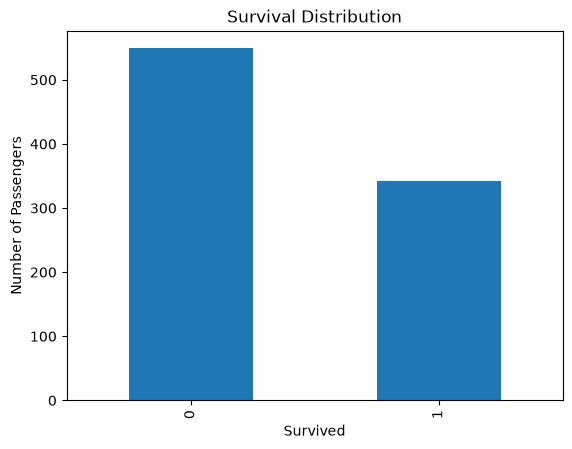

In [149]:
df["Survived"].value_counts().plot(kind="bar")

plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")
plt.show()

In [150]:
survival_by_sex = df.groupby("Sex")["Survived"].mean()
survival_by_sex

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

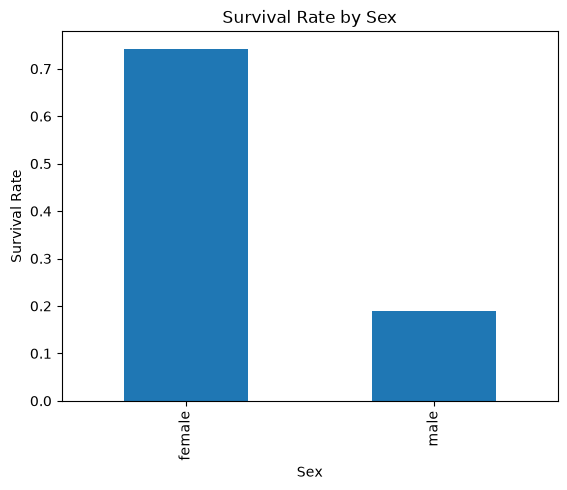

In [151]:
survival_by_sex.plot(kind="bar")

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.show()

In [152]:
survival_by_class = df.groupby("Pclass")["Survived"].mean()
survival_by_class


Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

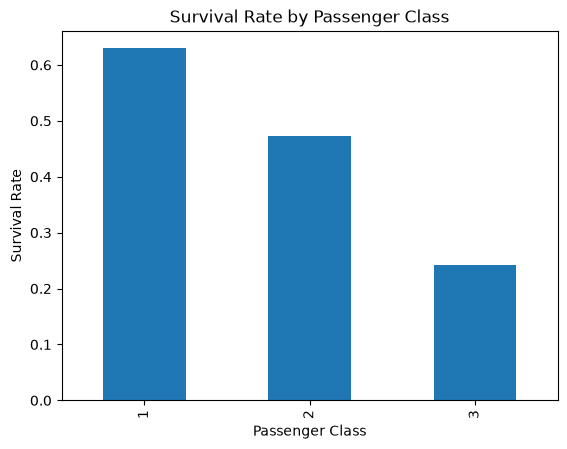

In [153]:
survival_by_class.plot(kind="bar")

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

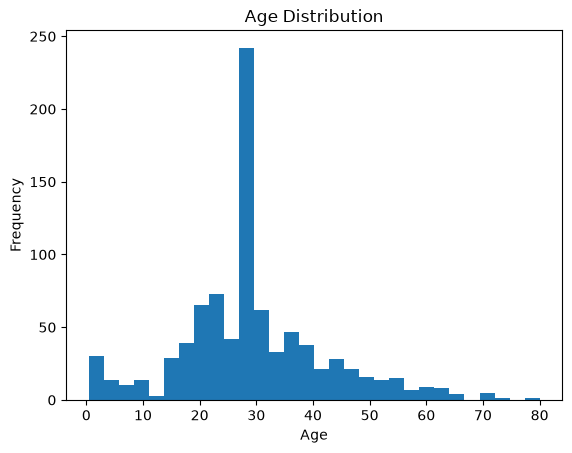

In [154]:
df["Age"].plot(kind="hist", bins=30)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

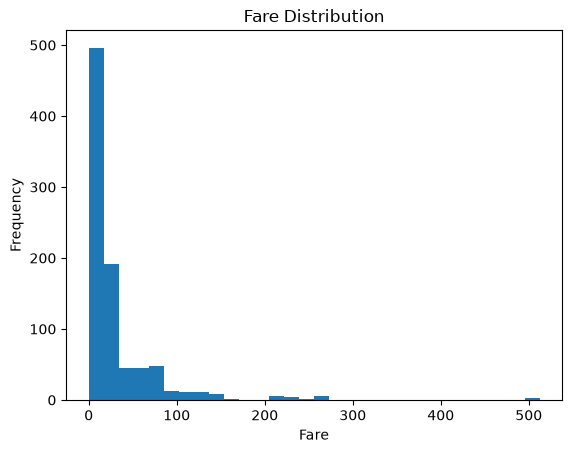

In [155]:
df["Fare"].plot(kind="hist", bins=30)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

In [156]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Step 7 Findings

Based on the exploratory data analysis:

- More passengers did not survive than survived.
- Survival rate differs by gender.
- Passenger class appears to be related to survival rate.
- Age and Fare show different distributions and may contain useful information for prediction.
- The dataset is now ready for feature and target separation.

## Step 8: Split Features and Target

In this step, we separate the dataset into input features and the target variable.

- `X` contains the independent variables used for prediction.
- `y` contains the target variable that the model needs to predict.

For this project, the target variable is `Survived`.

In [157]:
target_col = "Survived"

In [158]:
X = df.drop(columns=[target_col])
y = df[target_col]

In [159]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [160]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [161]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (891, 7)
y shape: (891,)


### Step 8 Findings

The dataset was separated into features and target.

- `X` contains the input features.
- `y` contains the target variable `Survived`.

The target column was removed from `X` to avoid data leakage.

## Step 9: Encode Categorical Values

In this step, we convert categorical text columns into numerical columns so that they can be used by machine learning models.

Machine learning models cannot directly understand text values such as `male`, `female`, `S`, `C`, or `Q`. Therefore, we use one-hot encoding to convert these categories into numerical format.

In [162]:
categorical_cols = X.select_dtypes(include=["object"]).columns

print("Categorical columns:")
print(categorical_cols)

Categorical columns:
Index(['Sex', 'Embarked'], dtype='str')


C:\Users\Jeewa's Lap\AppData\Local\Temp\ipykernel_43012\1477735621.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns


In [163]:
for col in categorical_cols:
    print(col)
    print(X[col].unique())
    print()

Sex
<StringArray>
['male', 'female']
Length: 2, dtype: str

Embarked
<StringArray>
['S', 'C', 'Q']
Length: 3, dtype: str



In [164]:
X_encoded = pd.get_dummies(X, drop_first=True, dtype=int)

In [165]:
X_encoded.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,1,0,1
1,1,38.0,1,0,71.2833,0,0,0
2,3,26.0,0,0,7.9250,0,0,1
3,1,35.0,1,0,53.1000,0,0,1
4,3,35.0,0,0,8.0500,1,0,1


In [166]:
print("Original X shape:", X.shape)
print("Encoded X shape:", X_encoded.shape)

Original X shape: (891, 7)
Encoded X shape: (891, 8)


In [167]:
X_encoded.columns

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q',
       'Embarked_S'],
      dtype='str')

### Step 9 Findings

The categorical columns `Sex` and `Embarked` were encoded using one-hot encoding.

After encoding:

- `Sex` was converted into a numerical dummy column.
- `Embarked` was converted into numerical dummy columns.
- The target column `Survived` was not encoded because it is already represented as 0 and 1.

The feature set is now fully numerical and ready for train/test splitting.

## Step 10: Train/Test Split

In this step, we split the dataset into training and testing sets.

The training set is used to train the machine learning model, while the testing set is used to evaluate how well the model performs on unseen data.

For this classification problem, we use stratified splitting to keep the target class distribution similar in both training and testing sets.

In [168]:
from sklearn.model_selection import train_test_split

In [169]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [170]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (712, 8)
X_test shape: (179, 8)
y_train shape: (712,)
y_test shape: (179,)


In [171]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training target distribution:
Survived
0    61.657303
1    38.342697
Name: proportion, dtype: float64

Testing target distribution:
Survived
0    61.452514
1    38.547486
Name: proportion, dtype: float64


### Step 10 Findings

The encoded feature set and target variable were split into training and testing sets.

- 80% of the data was used for training.
- 20% of the data was used for testing.
- Stratified splitting was used to preserve the class distribution of the target variable.

The data is now ready for feature scaling.

## Step 11: Scale Data

In this step, we scale the feature values using StandardScaler.

Feature scaling is important for algorithms such as Logistic Regression because these models can be affected by differences in feature ranges.

The scaler is fitted only on the training data to avoid data leakage.


In [172]:
from sklearn.preprocessing import StandardScaler

In [173]:
scaler = StandardScaler()

In [174]:
X_train_scaled = scaler.fit_transform(X_train)

In [175]:
X_test_scaled = scaler.transform(X_test)

In [176]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (712, 8)
X_test_scaled shape: (179, 8)


In [177]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

X_train_scaled_df.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0.829568,-0.112078,-0.465084,-0.466183,0.513812,0.742427,-0.289333,0.611978
1,-0.370945,-0.112078,-0.465084,-0.466183,-0.662563,0.742427,-0.289333,0.611978
2,-1.571457,-0.112078,-0.465084,-0.466183,3.955399,0.742427,-0.289333,0.611978
3,0.829568,-0.879807,-0.465084,0.727782,-0.467874,-1.346933,-0.289333,0.611978
4,-0.370945,0.118241,0.478335,0.727782,-0.115977,-1.346933,-0.289333,0.611978


### Step 11 Findings

The training and testing feature sets were scaled using StandardScaler.

- The scaler was fitted only on the training data.
- The same scaler was used to transform the testing data.
- This prevents data leakage and keeps the model evaluation fair.

The scaled data is now ready for model training.

## Step 12: Train Model

In this step, we train a baseline machine learning model using Logistic Regression.

Logistic Regression is suitable for this project because the target variable `Survived` has two classes:

- `0`: Passenger did not survive
- `1`: Passenger survived

The model is trained using the scaled training data.

In [178]:
from sklearn.linear_model import LogisticRegression

In [179]:
model = LogisticRegression(max_iter=1000, random_state=42)

In [180]:
model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [181]:
print("Model training completed successfully.")

Model training completed successfully.


### Step 12 Findings

A Logistic Regression model was trained using the scaled training data.

This model acts as the baseline classification model for predicting whether a Titanic passenger survived or not.

## Step 13: Make Predictions

In this step, we use the trained Logistic Regression model to make predictions on the test dataset.

The model predicts whether each passenger in the test set survived or not.

In [182]:
y_pred = model.predict(X_test_scaled)

In [183]:
y_pred[:10]

array([0, 0, 0, 0, 1, 0, 1, 0, 0, 0])

In [184]:
prediction_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

prediction_results.head(10)

,Actual,Predicted
0,0,0
1,0,0
2,1,0
3,0,0
4,1,1
5,1,0
6,1,1
7,0,0
8,0,0
9,0,0


In [185]:
pd.Series(y_pred).value_counts()

0    121
1     58
Name: count, dtype: int64

### Step 13 Findings

The trained Logistic Regression model was used to make predictions on the scaled test dataset.

The predictions contain two possible classes:

- `0`: Passenger did not survive
- `1`: Passenger survived

The actual and predicted values were compared to prepare for model evaluation.

## Step 14: Evaluate Model

In this step, we evaluate the trained Logistic Regression model using classification metrics.

Since this is a binary classification problem, we use accuracy, precision, recall, F1-score, and confusion matrix to understand model performance.

In [186]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [187]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8044692737430168


In [188]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [189]:
conf_matrix = confusion_matrix(y_test, y_pred)

print(conf_matrix)

[[98 12]
 [23 46]]


In [190]:
conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=["Actual Not Survived", "Actual Survived"],
    columns=["Predicted Not Survived", "Predicted Survived"]
)

conf_matrix_df

,Predicted Not Survived,Predicted Survived
Actual Not Survived,98,12
Actual Survived,23,46


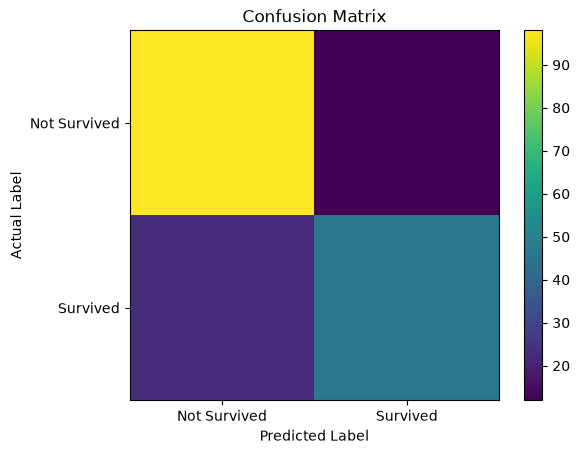

In [191]:
plt.imshow(conf_matrix)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.colorbar()
plt.xticks([0, 1], ["Not Survived", "Survived"])
plt.yticks([0, 1], ["Not Survived", "Survived"])
plt.show()

### Step 14 Findings

The Logistic Regression model was evaluated using classification metrics.

Evaluation metrics used:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

These metrics help understand how well the model predicts passenger survival on unseen test data.

## Step 15: Explain Results

In this step, we summarize the model performance and explain the final results.

The goal is to communicate what was done, how the model performed, and what the results mean in a clear and understandable way.

In [192]:
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 80.45%


In [193]:
summary = f"""
Final Model Summary

Problem Type:
- Binary Classification

Target Variable:
- Survived

Model Used:
- Logistic Regression

Evaluation:
- Accuracy: {accuracy * 100:.2f}%

Explanation:
The model was trained to predict whether a Titanic passenger survived or not.
The dataset was cleaned, categorical variables were encoded, features were scaled,
and the model was evaluated using classification metrics.

The accuracy score shows the overall percentage of correct predictions on the test dataset.
The classification report and confusion matrix give a deeper understanding of class-wise performance.
"""

print(summary)


Final Model Summary

Problem Type:
- Binary Classification

Target Variable:
- Survived

Model Used:
- Logistic Regression

Evaluation:
- Accuracy: 80.45%

Explanation:
The model was trained to predict whether a Titanic passenger survived or not.
The dataset was cleaned, categorical variables were encoded, features were scaled,
and the model was evaluated using classification metrics.

The accuracy score shows the overall percentage of correct predictions on the test dataset.
The classification report and confusion matrix give a deeper understanding of class-wise performance.



### Step 15 Findings

The Titanic survival prediction model was completed using an end-to-end machine learning workflow.

The workflow included:

- Loading and inspecting the dataset
- Identifying the target column
- Checking missing values and duplicates
- Cleaning the dataset
- Performing exploratory data analysis
- Separating features and target
- Encoding categorical variables
- Splitting the data into training and testing sets
- Scaling the feature data
- Training a Logistic Regression model
- Making predictions
- Evaluating the model

The model was evaluated using accuracy, precision, recall, F1-score, and confusion matrix.

Overall, the model provides a baseline approach for predicting Titanic passenger survival. Further improvements can be made by trying other models such as Random Forest, tuning hyperparameters, and performing additional feature engineering.

## Step 16: Model Improvement with Random Forest

In this step, we train a Random Forest classification model and compare it with the baseline Logistic Regression model.

Random Forest is a tree-based ensemble model that can capture non-linear relationships in the data. It does not require feature scaling, so we train it using the unscaled encoded features.

In [194]:
from sklearn.ensemble import RandomForestClassifier

In [195]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [196]:
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [197]:
rf_pred = rf_model.predict(X_test)

In [198]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.8156424581005587
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



In [199]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, rf_accuracy]
})

model_comparison

,Model,Accuracy
0,Logistic Regression,0.804469
1,Random Forest,0.815642


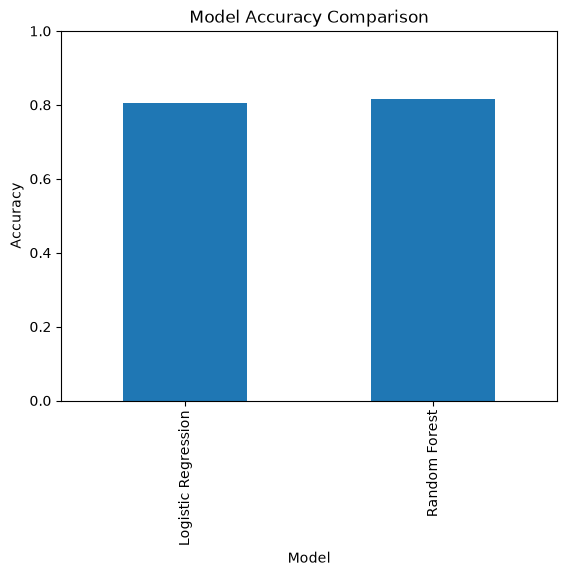

In [200]:
model_comparison.plot(x="Model", y="Accuracy", kind="bar", legend=False)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

In [201]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance

Fare          0.278484
Sex_male      0.263240
Age           0.252361
Pclass        0.079478
SibSp         0.053489
Parch         0.041017
Embarked_S    0.023194
Embarked_Q    0.008736
dtype: float64

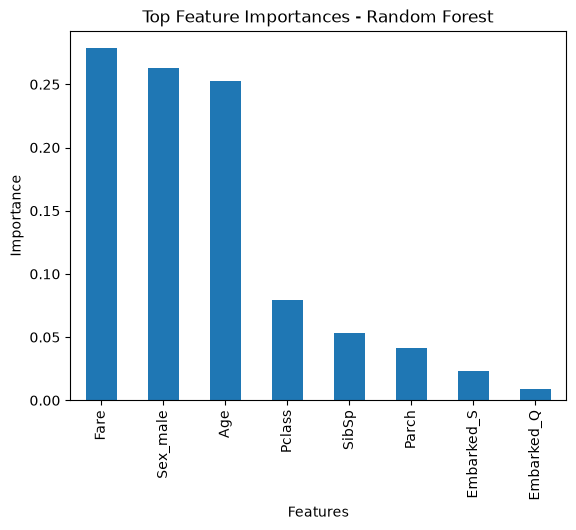

In [202]:
feature_importance.head(10).plot(kind="bar")

plt.title("Top Feature Importances - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

### Step 16 Findings

A Random Forest model was trained and compared with the baseline Logistic Regression model.

The model comparison helps identify whether a more flexible model improves prediction performance.

Random Forest also provides feature importance values, which help explain which features contributed most to survival prediction.

## Step 17: Save Outputs and Reports

In this step, we save important model outputs and visualizations into the `outputs` folder.

Saving outputs helps document the project results and makes the GitHub repository more professional and reproducible.

In [203]:
import os

os.makedirs("../outputs", exist_ok=True)

In [204]:
model_comparison.to_csv("../outputs/model_comparison.csv", index=False)

In [205]:
feature_importance.to_csv("../outputs/random_forest_feature_importance.csv", header=["importance"])

In [206]:
conf_matrix_df.to_csv("../outputs/logistic_regression_confusion_matrix.csv")

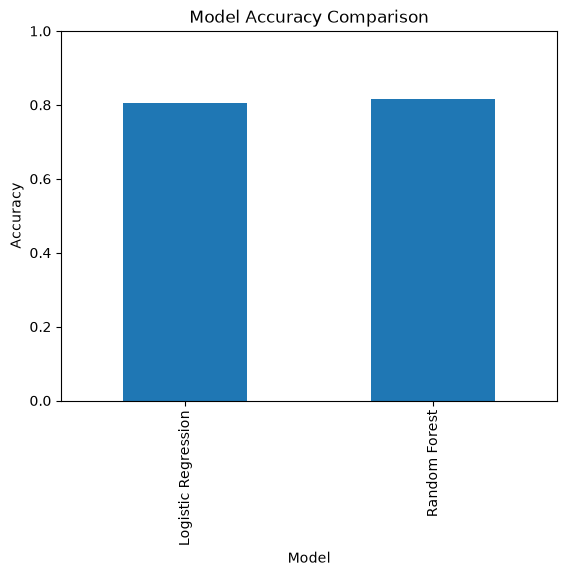

In [207]:
model_comparison.plot(x="Model", y="Accuracy", kind="bar", legend=False)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.savefig("../outputs/model_accuracy_comparison.png", bbox_inches="tight")
plt.show()


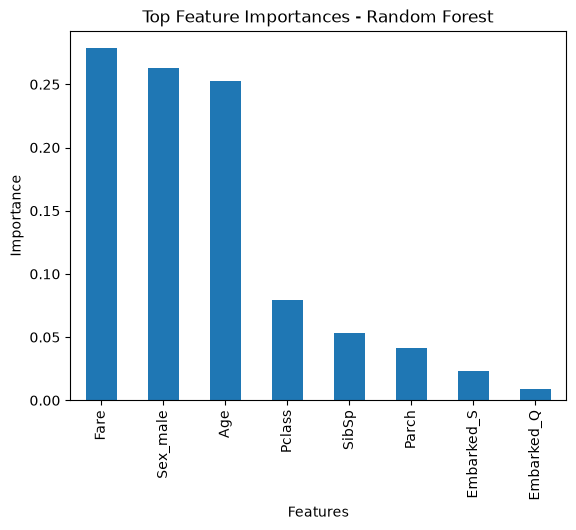

In [208]:
feature_importance.head(10).plot(kind="bar")

plt.title("Top Feature Importances - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.savefig("../outputs/random_forest_feature_importance.png", bbox_inches="tight")
plt.show()

In [209]:
os.listdir("../outputs")

['logistic_regression_confusion_matrix.csv',
 'model_accuracy_comparison.png',
 'model_comparison.csv',
 'random_forest_feature_importance.csv',
 'random_forest_feature_importance.png']

### Step 17 Findings

Important project outputs were saved into the `outputs` folder.

Saved outputs include:

- Model accuracy comparison
- Random Forest feature importance
- Logistic Regression confusion matrix
- Model comparison chart
- Feature importance chart

These files make the project easier to review and improve the quality of the GitHub portfolio repository.

## Step 18: Save Trained Model and Scaler

In this step, we save the trained machine learning model and scaler so they can be reused later without retraining.

Saving the model is important for deployment, testing, and future prediction tasks.

In [210]:
os.makedirs("../models", exist_ok=True)

In [211]:
import joblib

In [212]:
joblib.dump(model, "../models/logistic_regression_model.pkl")

['../models/logistic_regression_model.pkl']

In [213]:
joblib.dump(rf_model, "../models/random_forest_model.pkl")

['../models/random_forest_model.pkl']

In [214]:
joblib.dump(scaler, "../models/standard_scaler.pkl")

['../models/standard_scaler.pkl']

In [215]:
import json

feature_columns = list(X_encoded.columns)

with open("../models/feature_columns.json", "w") as f:
    json.dump(feature_columns, f)

In [216]:
os.listdir("../models")

['feature_columns.json',
 'logistic_regression_model.pkl',
 'random_forest_model.pkl',
 'standard_scaler.pkl']

### Step 18 Findings

The trained models and preprocessing objects were saved into the `models` folder.

Saved files:

- Logistic Regression model
- Random Forest model
- StandardScaler object
- Feature column names

This makes the project reusable because the trained models can be loaded later for predictions without retraining.

## Step 19: Load Saved Model and Make Future Prediction

In this step, we load the saved model, scaler, and feature columns, then test the model using a new passenger record.

This simulates how the trained model can be reused later for future predictions without retraining.

In [217]:
import joblib
import json

loaded_lr_model = joblib.load("../models/logistic_regression_model.pkl")
loaded_scaler = joblib.load("../models/standard_scaler.pkl")

with open("../models/feature_columns.json", "r") as f:
    loaded_feature_columns = json.load(f)

In [218]:
new_passenger = pd.DataFrame({
    "Pclass": [3],
    "Sex": ["male"],
    "Age": [25],
    "SibSp": [0],
    "Parch": [0],
    "Fare": [7.25],
    "Embarked": ["S"]
})

new_passenger

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,25,0,0,7.25,S


In [219]:
new_passenger_encoded = pd.get_dummies(new_passenger, drop_first=True, dtype=int)
new_passenger_encoded

,Pclass,Age,SibSp,Parch,Fare
0,3,25,0,0,7.25


In [220]:
new_passenger_encoded = new_passenger_encoded.reindex(
    columns=loaded_feature_columns,
    fill_value=0
)

new_passenger_encoded

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,25,0,0,7.25,0,0,0


In [221]:
new_passenger_scaled = loaded_scaler.transform(new_passenger_encoded)

In [222]:
new_prediction = loaded_lr_model.predict(new_passenger_scaled)

print("Prediction:", new_prediction[0])

Prediction: 1


In [223]:
if new_prediction[0] == 1:
    print("Predicted Result: Survived")
else:
    print("Predicted Result: Not Survived")

Predicted Result: Survived


In [224]:
prediction_probability = loaded_lr_model.predict_proba(new_passenger_scaled)

print("Probability of Not Survived:", prediction_probability[0][0])
print("Probability of Survived:", prediction_probability[0][1])

Probability of Not Survived: 0.30687515841861734
Probability of Survived: 0.6931248415813827


### Step 19 Findings

The saved Logistic Regression model, scaler, and feature column list were loaded successfully.

A new passenger record was created, encoded, aligned with the training feature columns, scaled, and passed into the trained model for prediction.

This confirms that the trained model can be reused for future predictions without retraining.